In [3]:
%cd /content
!rm -rf mccain-internship
!git clone https://github.com/PushkargithubCSE/mccain-internship.git
%cd mccain-internship/week-3/potato-finetuning
!pwd

/content
Cloning into 'mccain-internship'...
remote: Enumerating objects: 534, done.
remote: Counting objects: 100% (534/534), done.
remote: Compressing objects: 100% (392/392), done.
remote: Total 534 (delta 131), reused 482 (delta 85), pack-reused 0 (from 0)
Receiving objects: 100% (534/534), 21.48 MiB | 29.81 MiB/s, done.
Resolving deltas: 100% (131/131), done.
/content/mccain-internship/week-3/potato-finetuning
/content/mccain-internship/week-3/potato-finetuning


In [4]:
!pip install -q roboflow python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 121.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.6 MB/s eta 0:00:00


In [ ]:
import os
from dotenv import load_dotenv

PROJECT_PATH = "/content/mccain-internship/week-3/potato-finetuning"
load_dotenv(f"{PROJECT_PATH}/.env")

api_key = os.getenv("ROBOFLOW_API_KEY")
if not api_key:
    raise RuntimeError("ROBOFLOW_API_KEY is missing from the project .env file")

print("Roboflow API key loaded:", bool(api_key))

✓ .env file created at: /content/mccain-internship/week-3/potato-finetuning/.env


In [7]:
import os
from dotenv import load_dotenv

PROJECT_PATH = "/content/mccain-internship/week-3/potato-finetuning"
load_dotenv(f"{PROJECT_PATH}/.env")

api_key = os.getenv('ROBOFLOW_API_KEY')
print("Key loaded:", bool(api_key))
print("Key starts with:", api_key[:4] + "..." if api_key else "MISSING")

Key loaded: True
Key starts with: ERYw...


In [8]:
from roboflow import Roboflow

rf = Roboflow(api_key=api_key)
project = rf.workspace("pushkar-chandra").project("object-detection-yntmm")
version = project.version(1)
dataset = version.download("coco")

print(f"✓ Dataset downloaded to: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Object-Detection-1 in coco:: 100%|██████████| 21/21 [00:00<00:00, 4521.35it/s]

✓ Dataset downloaded to: /content/mccain-internship/week-3/potato-finetuning/Object-Detection-1


In [9]:
import os
import json

dataset_path = dataset.location
print(f"Dataset location: {dataset_path}\n")

for split in ['train', 'valid', 'test']:
    split_path = f'{dataset_path}/{split}'
    if os.path.exists(split_path):
        images = [f for f in os.listdir(split_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
        ann_path = f'{split_path}/_annotations.coco.json'

        print(f"[{split.upper()}]")
        print(f"  Images: {len(images)}")

        if os.path.exists(ann_path):
            with open(ann_path) as f:
                coco_data = json.load(f)
            print(f"  Annotations: {len(coco_data['annotations'])} boxes")
            print(f"  Categories: {[c['name'] for c in coco_data['categories']]}")
        print()
    else:
        print(f"[{split.upper()}] — folder not found\n")

Dataset location: /content/mccain-internship/week-3/potato-finetuning/Object-Detection-1

[TRAIN]
  Images: 11
  Annotations: 15 boxes
  Categories: ['Object-Detection', 'Object-Detection']

[VALID]
  Images: 3
  Annotations: 3 boxes
  Categories: ['Object-Detection', 'Object-Detection']

[TEST]
  Images: 2
  Annotations: 3 boxes
  Categories: ['Object-Detection', 'Object-Detection']



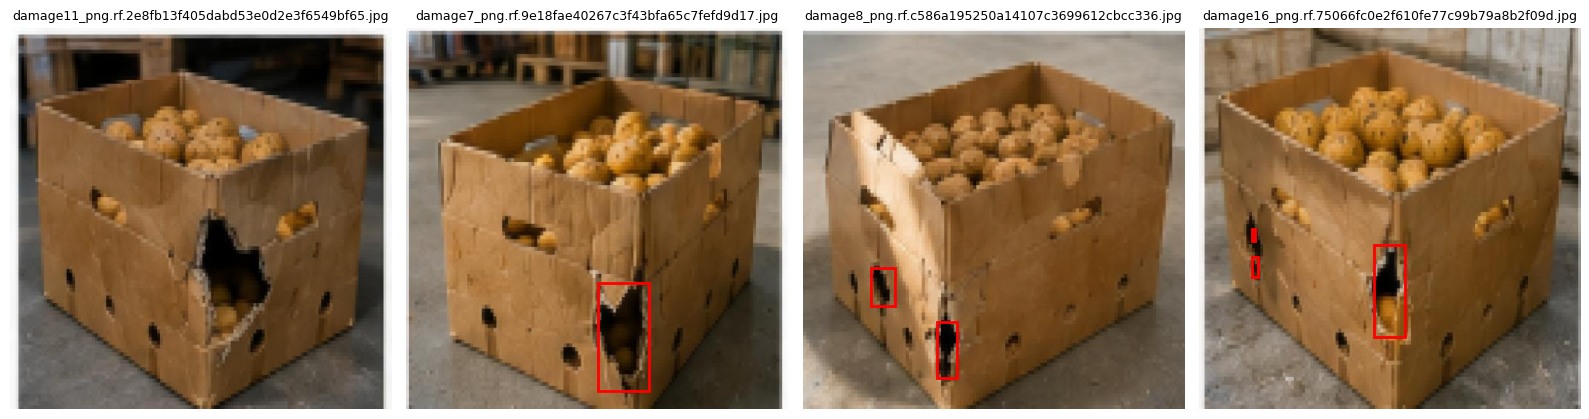

✓ Sample verification image saved


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import json
import os

train_path = f'{dataset.location}/train'
ann_path = f'{train_path}/_annotations.coco.json'

with open(ann_path) as f:
    coco_data = json.load(f)

# Build image_id -> filename map
img_map = {img['id']: img['file_name'] for img in coco_data['images']}

# Show first 4 annotated images
fig, axes = plt.subplots(1, min(4, len(coco_data['images'])), figsize=(16, 5))
if len(coco_data['images']) == 1:
    axes = [axes]

for idx, img_info in enumerate(coco_data['images'][:4]):
    img_path = f'{train_path}/{img_info["file_name"]}'
    img = Image.open(img_path)

    ax = axes[idx]
    ax.imshow(img)

    # Draw all boxes belonging to this image
    for ann in coco_data['annotations']:
        if ann['image_id'] == img_info['id']:
            x, y, w, h = ann['bbox']
            rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)

    ax.set_title(img_info['file_name'], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/data/roboflow_sample_check.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Sample verification image saved")